# 6 - Python Analysis of Phase 1
In this notebook, I execute the python analysis for phase 1. The first anlaysis is the Lexical Keyness one with Log Likelihood and Log Ratio measures with a funnel plot summarizing the main findings. Next, sentiment analysis through the transformer model Parlasent is done. The same analyses are repeated for the Baseline corpus. Then Cohen's d effect sizes measured between MBH (Mother and Baby Home) corpus and Baseline corpus are executed. The Structural Topic Modelling (STM) of this phase can be found in the R file. 

In [1]:
# Load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction import text

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk
from IPython.display import HTML, display
from adjustText import adjust_text

import numpy as np
import pandas as pd
from math import factorial
from scipy import stats
from scipy.stats import multinomial
from scipy.stats import mannwhitneyu
from statsmodels.nonparametric.smoothers_lowess import lowess




import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt

from unidecode import unidecode

#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')


import seaborn as sns # better vis
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from nltk.corpus import opinion_lexicon
from nltk import word_tokenize
nltk.download('opinion_lexicon')
nltk.download('punkt')

from tqdm import tqdm

import spacy
from pprint import pprint

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from simpletransformers.classification import ClassificationModel
import torch

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     /Users/moira/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /Users/moira/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/opt/anaconda3/envs/text_analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data
df_merged_clean = pd.read_csv('data/df_merged_clean.csv')

In [3]:
len(df_merged_clean)

2224

In [4]:
df_merged_clean.columns

Index(['date', 'house_x', 'speaker', 'text', 'clean_text', 'text_length',
       'speaker_norm', 'taoiseach_at_time', 'fullName', 'firstName',
       'lastName', 'house_y', 'constituency', 'party', 'membership_start',
       'membership_end', 'gender_guess', 'in_parliament', 'in_government'],
      dtype='object')

In [5]:
# Opposition vs Government amount of speeches
print(df_merged_clean['in_government'].value_counts())

in_government
0    1384
1     840
Name: count, dtype: int64


# LOG LIKELIHOOD

In [6]:
df_merged_clean.columns

Index(['date', 'house_x', 'speaker', 'text', 'clean_text', 'text_length',
       'speaker_norm', 'taoiseach_at_time', 'fullName', 'firstName',
       'lastName', 'house_y', 'constituency', 'party', 'membership_start',
       'membership_end', 'gender_guess', 'in_parliament', 'in_government'],
      dtype='object')

The LL analysis answers: is this word used significantly more by one group than the other, accounting for corpus size differences? It is a significance test.

In [7]:
# Log-Likelihood

# Computes log-likelihood (LL) keyness scores to identify words that are statistically overrepresented in Government vs Opposition speech.
def get_keyness(df, group_col):
    # 1. Vectorize the text
    # Convert cleaned text into a document–term matrix (DTM)
    # min_df=5 removes very rare words
    vec = CountVectorizer(stop_words='english', min_df=5)
    dtm = vec.fit_transform(df['clean_text'].fillna(""))
    vocab = vec.get_feature_names_out()
    
    # 2. Split the Document-Term Matrix by Group (Gov vs Opp boolean)
    gov_mask = (df[group_col] == 1).values
    opp_mask = (df[group_col] == 0).values
    
    # Total number of tokens in each group from the matrix (because unbalanced)
    # These values are used to calculate expected frequencies
    gov_counts = np.asarray(dtm[gov_mask].sum(axis=0)).flatten()
    opp_counts = np.asarray(dtm[opp_mask].sum(axis=0)).flatten()
    
    # 3. Calculate total corpus sizes for each group
    size_gov = gov_counts.sum()
    size_opp = opp_counts.sum()
    
    ll_results = []
    
    # 4. Loop through vocab and calculate Log-Likelihood
    for i, word in enumerate(vocab):
        # Observed frequencies of the word in each group
        a = gov_counts[i] # Obs 1
        b = opp_counts[i] # Obs 2
        
        # Expected values (E = RowTotal * ColTotal / GrandTotal), word is distributed proportionally to corpus size
        e1 = size_gov * (a + b) / (size_gov + size_opp)
        e2 = size_opp * (a + b) / (size_gov + size_opp)
        
        # Log-likelihood formula: LL = 2 * [ a*ln(a/e1) + b*ln(b/e2) ]
        # Terms with zero observed frequency contribute 0
        # I use np.log to avoid errors if count is 0
        term1 = a * np.log(a / e1) if a > 0 else 0
        term2 = b * np.log(b / e2) if b > 0 else 0
        ll = 2 * (term1 + term2)
        
        # Determine which group the word "belongs" to (gov vs opp)
        rel_gov = a / size_gov
        rel_opp = b / size_opp
        target_group = "Government" if rel_gov > rel_opp else "Opposition"
        
        ll_results.append({
            'word': word, 
            'LL': ll, 
            'typical_of': target_group,
            'count_gov': a, 
            'count_opp': b
        })
        
    return pd.DataFrame(ll_results).sort_values('LL', ascending=False)

# Execute
keyness_df = get_keyness(df_merged_clean, 'in_government')

print("--- Statistically Significant Framing Words ---")
# LL > 3.84 is p < 0.05, LL > 10.83 is p < 0.001
display(keyness_df[keyness_df['LL'] > 10.83].head(50))

--- Statistically Significant Framing Words ---


,word,LL,typical_of,count_gov,count_opp
6831,senator,842.016408,Government,1065,282
6832,senators,341.275613,Government,391,89
6464,residents,249.439907,Government,385,131
7188,state,225.044614,Opposition,1160,2845
6092,raised,202.145066,Government,533,287
5523,people,196.489054,Opposition,1857,4033
3259,forced,170.199401,Opposition,92,497
6901,shall,167.085587,Government,301,120
7479,taoiseach,161.892050,Opposition,140,609
6586,rights,138.911397,Opposition,389,1115


In [8]:
# Top 50 for Government
gov_top_50 = keyness_df[
    (keyness_df['typical_of'] == 'Government') & (keyness_df['LL'] > 10.83)
].head(50)

# Top 50 for Opposition
opp_top_50 = keyness_df[
    (keyness_df['typical_of'] == 'Opposition') & (keyness_df['LL'] > 10.83)
].head(50)

print("--- TOP 50 GOVERNMENT KEY WORDS ---")
display(gov_top_50[['word', 'LL', 'count_gov', 'count_opp']])

print("\n--- TOP 50 OPPOSITION KEY WORDS ---")
display(opp_top_50[['word', 'LL', 'count_gov', 'count_opp']])

--- TOP 50 GOVERNMENT KEY WORDS ---


,word,LL,count_gov,count_opp
6831,senator,842.016408,1065,282
6832,senators,341.275613,391,89
6464,residents,249.439907,385,131
6092,raised,202.145066,533,287
6901,shall,167.085587,301,120
8290,work,136.436006,1187,1072
1612,commission,126.391573,1908,1962
5984,provides,124.000773,251,111
1982,county,121.468609,586,433
7692,tracing,118.391954,332,186



--- TOP 50 OPPOSITION KEY WORDS ---


,word,LL,count_gov,count_opp
7188,state,225.044614,1160,2845
5523,people,196.489054,1857,4033
3259,forced,170.199401,92,497
7479,taoiseach,161.892050,140,609
6586,rights,138.911397,389,1115
8070,victims,103.912914,121,466
7417,survivors,98.087132,1244,2573
6857,separation,97.739830,21,190
2522,does,83.906702,338,879
431,adopted,82.055073,188,572


The log-ratio analysis below answers: how much more likely is this word in one group relative to the other? It is an effect size measure.

In [9]:
# Frequency Filter (e.g. Min 5 occurrences across the whole corpus)
min_frequency = 0 # for now 0
keyness_df['total_count'] = keyness_df['count_gov'] + keyness_df['count_opp']
keyness_df = keyness_df[keyness_df['total_count'] >= min_frequency].copy()

# Filter out common names/proper nouns 
names_to_ignore = ['buttimer', 'mcfadden', 'conwaywalsh', 'cassells', 'coghlan', 'ahearn', 'gloster']
keyness_df = keyness_df[~keyness_df['word'].isin(names_to_ignore)]

# Calculate Log-Ratio to determine effect size (how much more likely a group uses a word)
# Add small constant to avoid division by zeros
keyness_df['rel_gov'] = (keyness_df['count_gov'] + 0.1) / keyness_df['count_gov'].sum()
keyness_df['rel_opp'] = (keyness_df['count_opp'] + 0.1) / keyness_df['count_opp'].sum()
keyness_df['log_ratio'] = np.log2(keyness_df['rel_gov'] / keyness_df['rel_opp'])

# Identify Managerial vs. Exploratory Framing
managerial_words = keyness_df[keyness_df['log_ratio'] > 1].sort_values('log_ratio', ascending=False).head(20)
exploratory_words = keyness_df[keyness_df['log_ratio'] < -1].sort_values('log_ratio', ascending=True).head(20)

print("--- TOP MANAGERIAL FRAMES (Gov more likely) ---")
print(managerial_words[['word', 'log_ratio']])

print("\n--- TOP EXPLORATORY FRAMES (Opp more likely) ---")
print(exploratory_words[['word', 'log_ratio']])

--- TOP MANAGERIAL FRAMES (Gov more likely) ---
                word  log_ratio
7321         subsidy   7.703607
480    affordability   7.597479
6753       schoolage   7.597479
6558        reviewer   7.358472
6837  sensationalism   7.222267
8338           yeats   7.222267
7941        unjustly   7.071851
4241         jackson   7.071851
2128          davitt   7.071851
5918       projected   6.903906
4668         malcolm   6.903906
2079          currie   6.713803
1812       constance   6.713803
2634         earnest   6.713803
2791       enhancing   6.713803
732      archdiocese   6.713803
1515     cliffordlee   6.713803
4886        ministry   6.713803
5764        prejudge   6.494793
5511          pearse   6.494793

--- TOP EXPLORATORY FRAMES (Opp more likely) ---
                 word  log_ratio
2557              dpc  -7.716715
2985  experimentation  -7.348833
3002        exploited  -7.287693
5173              níl  -7.223847
1462             chur  -7.157043
5175             níos  -7.013373

In [10]:
pd.set_option('display.max_rows', None)

# Words appearing only in Government
gov_only = keyness_df[(keyness_df['count_gov'] > 0) & (keyness_df['count_opp'] == 0)]
print("--- Words ONLY in Government ---")
print(gov_only[['word', 'count_gov', 'count_opp']])

# Words appearing only in Opposition
opp_only = keyness_df[(keyness_df['count_opp'] > 0) & (keyness_df['count_gov'] == 0)]
print("\n--- Words ONLY in Opposition ---")
print(opp_only[['word', 'count_gov', 'count_opp']])

# # Words appearing in BOTH
# both = keyness_df[(keyness_df['count_gov'] > 0) & (keyness_df['count_opp'] > 0)]
# print("\n--- Words in BOTH Government and Opposition ---")
# print(both[['word', 'count_gov', 'count_opp']])


--- Words ONLY in Government ---
                word  count_gov  count_opp
7321         subsidy         14          0
6753       schoolage         13          0
480    affordability         13          0
6558        reviewer         11          0
6837  sensationalism         10          0
8338           yeats         10          0
7941        unjustly          9          0
4241         jackson          9          0
2128          davitt          9          0
5918       projected          8          0
4668         malcolm          8          0
1812       constance          7          0
2079          currie          7          0
2791       enhancing          7          0
732      archdiocese          7          0
1515     cliffordlee          7          0
2634         earnest          7          0
4886        ministry          7          0
4491          leyden          6          0
2786     engineering          6          0
4988         mullins          6          0
5157             nui 

### Funnel Plot
Monroe et al. style (weighted log-odds plot)



In [11]:
gov_texts = df_merged_clean[df_merged_clean['in_government'] == 1]['clean_text'].fillna("").tolist()
opp_texts = df_merged_clean[df_merged_clean['in_government'] == 0]['clean_text'].fillna("").tolist()

print(len(gov_texts), len(opp_texts))  # should print 840, 1384

vectorizer = CountVectorizer(min_df=5)
vectorizer.fit(gov_texts + opp_texts)
vocab = vectorizer.get_feature_names_out()

gov_counts = np.asarray(vectorizer.transform(gov_texts).sum(axis=0)).flatten()
opp_counts = np.asarray(vectorizer.transform(opp_texts).sum(axis=0)).flatten()

gov_series = pd.Series(gov_counts, index=vocab)
opp_series = pd.Series(opp_counts, index=vocab)

print("done:", len(vocab), "words in vocabulary")

840 1384
done: 8640 words in vocabulary


In [12]:
# 1. BUILD WORD COUNT VECTORS PER GROUP

gov_texts = df_merged_clean[df_merged_clean['in_government'] == 1]['clean_text'].fillna("").tolist()
opp_texts = df_merged_clean[df_merged_clean['in_government'] == 0]['clean_text'].fillna("").tolist()

print(len(gov_texts), len(opp_texts))  # should print 840 1384

vectorizer = CountVectorizer(min_df=5, stop_words='english')
vectorizer.fit(gov_texts + opp_texts)
vocab = vectorizer.get_feature_names_out()

gov_counts = np.asarray(vectorizer.transform(gov_texts).sum(axis=0)).flatten()
opp_counts = np.asarray(vectorizer.transform(opp_texts).sum(axis=0)).flatten()

gov_series = pd.Series(gov_counts, index=vocab)
opp_series = pd.Series(opp_counts, index=vocab)

print("done:", len(vocab), "words in vocabulary")

840 1384
done: 8362 words in vocabulary


In [13]:
# 2. MONROE ET AL. (2008) WEIGHTED LOG-ODDS WITH DIRICHLET PRIOR
def monroe_log_odds(counts_a, counts_b, alpha=0.01):
    """
    Monroe et al. (2008) weighted log-odds ratio with Dirichlet prior.
    Group A = focal group (positive z = distinctive to A).
    alpha: prior weight (smoothing). Monroe recommend alpha << 1.
    Returns DataFrame with log_odds, variance, z_score, total_count.
    """
    vocab   = counts_a.index.union(counts_b.index)
    a       = counts_a.reindex(vocab, fill_value=0).astype(float)
    b       = counts_b.reindex(vocab, fill_value=0).astype(float)
    n_a     = a.sum()
    n_b     = b.sum()
    n       = n_a + n_b

    # Corpus-wide background prior (Monroe eq. 16)
    prior   = alpha * (a + b) / n

    # Smoothed counts
    a_s     = a + prior
    b_s     = b + prior
    n_a_s   = n_a + alpha
    n_b_s   = n_b + alpha

    # Log-odds ratio (Monroe eq. 19)
    log_odds = (np.log(a_s) - np.log(n_a_s - a_s) -
                np.log(b_s) + np.log(n_b_s - b_s))

    # Variance (Monroe eq. 22)
    variance = 1.0/a_s + 1.0/b_s

    # Z-score (Monroe eq. 23) — this IS the significance criterion
    z_score  = log_odds / np.sqrt(variance)

    return pd.DataFrame({
        'log_odds':    log_odds,
        'variance':    variance,
        'z_score':     z_score,   # positive = distinctive to group A (Government)
        'total_count': a + b
    }, index=vocab)

results = monroe_log_odds(gov_series, opp_series, alpha=0.01)
results['log_total'] = np.log10(results['total_count'])
results['typical_of'] = np.where(results['z_score'] > 0, 'Government', 'Opposition')

In [14]:
# 3. FILTER NOISE WORDS
names_to_ignore = [
    'buttimer', 'mcfadden', 'conwaywalsh', 'cassells', 'coghlan',
    'ahearn', 'gloster', 'markievicz', 'tommy', 'norris',
    'reviewer', 'yeats', 'sensationalism', 'schoolage', 'ncs',
    '49', '219', 'stamullen', 'ardagh', 'carlow', 'northeast',
    'postrecovery', 'commemorative', '2025', 'níl', 'pios', 'chur',
    'leo', 'kyne', 'originals', 'níos', 'ruairí', 'sage', 'plots',
    'quotes', 'column', 'railway', 'railways'
]
results = results[~results.index.isin(names_to_ignore)]

In [15]:
# 4. SIGNIFICANCE
# Z > 1.96  → p < 0.05 (two-tailed)
# Z > 3.29  → p < 0.001 (two-tailed)
# The funnel IS the z-score threshold — no separate LL needed

gov_sig  = results[(results['z_score'] >  3.29)]
opp_sig  = results[(results['z_score'] < -3.29)]
noise    = results[(results['z_score'].abs() <= 3.29)]

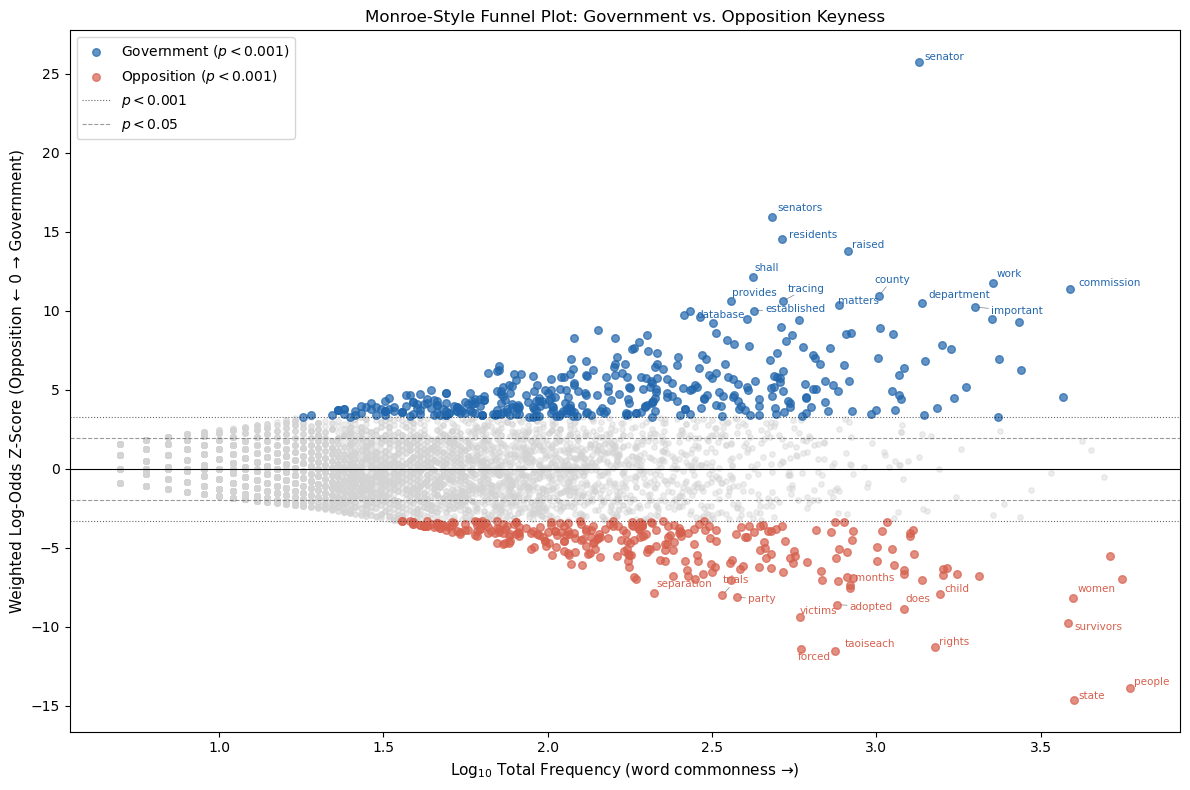

In [16]:
# 5. PLOT
fig, ax = plt.subplots(figsize=(12, 8))

# Noise
ax.scatter(noise['log_total'], noise['z_score'],
           color='lightgrey', alpha=0.4, s=15, zorder=1)

# Significant words
ax.scatter(gov_sig['log_total'], gov_sig['z_score'],
           color='#2166AC', alpha=0.7, s=30, zorder=2,
           label='Government ($p < 0.001$)')
ax.scatter(opp_sig['log_total'], opp_sig['z_score'],
           color='#D6604D', alpha=0.7, s=30, zorder=2,
           label='Opposition ($p < 0.001$)')

# Funnel boundaries — horizontal lines due to z-score
ax.axhline( 3.29, color='black', linestyle=':', linewidth=0.8,
            alpha=0.6, label='$p < 0.001$')
ax.axhline(-3.29, color='black', linestyle=':', linewidth=0.8,
            alpha=0.6)
ax.axhline( 1.96, color='black', linestyle='--', linewidth=0.8,
            alpha=0.4, label='$p < 0.05$')
ax.axhline(-1.96, color='black', linestyle='--', linewidth=0.8,
            alpha=0.4)
ax.axhline(0, color='black', linewidth=0.8)

# Label top 15 each side
top_gov = gov_sig.nlargest(15, 'z_score')
top_opp = opp_sig.nsmallest(15, 'z_score')

texts = []
for _, row in pd.concat([top_gov, top_opp]).iterrows():
    texts.append(ax.text(
        row['log_total'], row['z_score'], row.name,
        fontsize=7.5,
        color='#2166AC' if row['typical_of'] == 'Government' else '#D6604D'
    ))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))

ax.set_xlabel('Log$_{10}$ Total Frequency (word commonness →)', fontsize=11)
ax.set_ylabel('Weighted Log-Odds Z-Score (Opposition ← 0 → Government)',
              fontsize=11)
ax.set_title(
    'Monroe-Style Funnel Plot: Government vs. Opposition Keyness',
    fontsize=12)

ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('figures/monroe_funnel_plot.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/monroe_funnel_plot.pdf', bbox_inches='tight')
plt.show()

# PARLASENT

In [17]:
# not rerunning parlasent now as it takes 85 minutes
RERUN_PARLASENT = False
RERUN_BASELINE_PARLASENT = False

In [18]:
if RERUN_PARLASENT or RERUN_BASELINE_PARLASENT:
    print("Initializing ParlaSent model...")
    model_args = {
        "use_multiprocessing": False,
        "process_count": 1,
        "silent": True
    }
    parlasent_model = ClassificationModel(
        "xlmroberta",
        "classla/xlm-r-parlasent",
        use_cuda=False,
        args=model_args
    )
    print("Model loaded.")
else:
    print("Skipping model initialization (loading scores from disk).")

Skipping model initialization (loading scores from disk).


In [19]:
if RERUN_PARLASENT:
    # 1. Strip speaker name but keep punctuation for sentence tokenization
    def remove_speaker_name_only(text):
        if isinstance(text, str):
            return re.sub(r'^.*?\n', '', text)
        return text

    df_merged_clean['text_for_sent'] = df_merged_clean['text'].apply(
        remove_speaker_name_only)

    # 2. Tokenize each speech into sentences
    df_merged_clean['sentences'] = df_merged_clean['text_for_sent'].fillna(
        "").apply(sent_tokenize)

    # 3. Build a flat list of (speech_index, sentence) pairs
    records = []
    for idx, row in df_merged_clean.iterrows():
        for sent in row['sentences']:
            if len(sent.strip()) > 10:
                records.append({'speech_idx': idx, 'sentence': sent})

    sentences_df = pd.DataFrame(records)
    print(f"Total sentences: {len(sentences_df)}")
    print(f"Mean sentences per speech: {len(sentences_df) / len(df_merged_clean):.1f}")

    # 4. Run ParlaSent on all sentences (~90 minutes on CPU)
    print("Running ParlaSent on sentences...")
    texts = sentences_df['sentence'].tolist()
    predictions, raw_outputs = parlasent_model.predict(texts)
    sentences_df['sent_score'] = [float(logits[0]) for logits in raw_outputs]
    sentences_df['sent_score'] = sentences_df['sent_score'].clip(0, 5)

    # 5. Aggregate back to speech level
    speech_sentiment = sentences_df.groupby('speech_idx')['sent_score'].mean()
    df_merged_clean['parlasent_sentiment_sent'] = df_merged_clean.index.map(
        speech_sentiment)

    # 6. Save to disk
    df_merged_clean.to_csv('data/df_merged_clean_sentimentscores.csv', index=False)
    print("Saved to data/df_merged_clean_sentimentscores.csv")

else:
    print("Loading precomputed scores from disk...")
    df_merged_clean = pd.read_csv('data/df_merged_clean_sentimentscores.csv')
    df_merged_clean['date'] = pd.to_datetime(df_merged_clean['date'])
    print("Loaded.")

# Verify
print("\nSentence-level ParlaSent scores:")
print(df_merged_clean['parlasent_sentiment_sent'].describe())

Loading precomputed scores from disk...
Loaded.

Sentence-level ParlaSent scores:
count    2224.000000
mean        2.077768
std         0.758922
min         0.000000
25%         1.543151
50%         2.039834
75%         2.605771
max         4.573372
Name: parlasent_sentiment_sent, dtype: float64


In [20]:
df_merged_clean.columns

Index(['date', 'house_x', 'speaker', 'text', 'clean_text', 'text_length',
       'speaker_norm', 'taoiseach_at_time', 'fullName', 'firstName',
       'lastName', 'house_y', 'constituency', 'party', 'membership_start',
       'membership_end', 'gender_guess', 'in_parliament', 'in_government',
       'word_count', 'parlasent_sentiment', 'sentences', 'text_for_sent',
       'parlasent_sentiment_sent'],
      dtype='object')

In [21]:
# Calculate Variance and Mean
regime_stats = df_merged_clean.groupby('in_government')['parlasent_sentiment_sent'].agg(['mean', 'std', 'var', 'count']).reset_index()
regime_stats['Regime'] = regime_stats['in_government'].map({1: 'Managerial (Gov)', 0: 'Exploratory (Opp)'})

print(regime_stats[['Regime', 'mean', 'std', 'count']])

# Statistical Significance (Mann-Whitney U Test)
u_stat, p_val = mannwhitneyu(df_merged_clean[df_merged_clean['in_government']==1]['parlasent_sentiment_sent'],
                             df_merged_clean[df_merged_clean['in_government']==0]['parlasent_sentiment_sent'])
print(f"\nSignificance of the Sentiment Gap (p-value): {p_val}")

              Regime      mean       std  count
0  Exploratory (Opp)  1.809478  0.689177   1384
1   Managerial (Gov)  2.519807  0.654800    840

Significance of the Sentiment Gap (p-value): 1.0569704256451107e-107


In [22]:
gov = df_merged_clean[df_merged_clean['in_government'] == 1]['parlasent_sentiment_sent']
opp = df_merged_clean[df_merged_clean['in_government'] == 0]['parlasent_sentiment_sent']

# Cohen's d
d = (gov.mean() - opp.mean()) / np.sqrt((gov.std()**2 + opp.std()**2) / 2)
print(f"Cohen's d MBH: {d:.3f}")

# Mann Whitney U
u_stat, p_val = stats.mannwhitneyu(gov, opp, alternative='two-sided')
print(f"U = {u_stat:.0f}, p = {p_val:.3e}")

Cohen's d MBH: 1.057
U = 904949, p = 1.057e-107


/var/folders/__/k0nszvtx03q_x5mm5gp8l0v40000gn/T/ipykernel_5766/3617383889.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_sentiment = (df_merged_clean.groupby([pd.Grouper(key='date', freq='M'), 'in_government'])['parlasent_sentiment_sent'].mean()- 2.5).unstack()


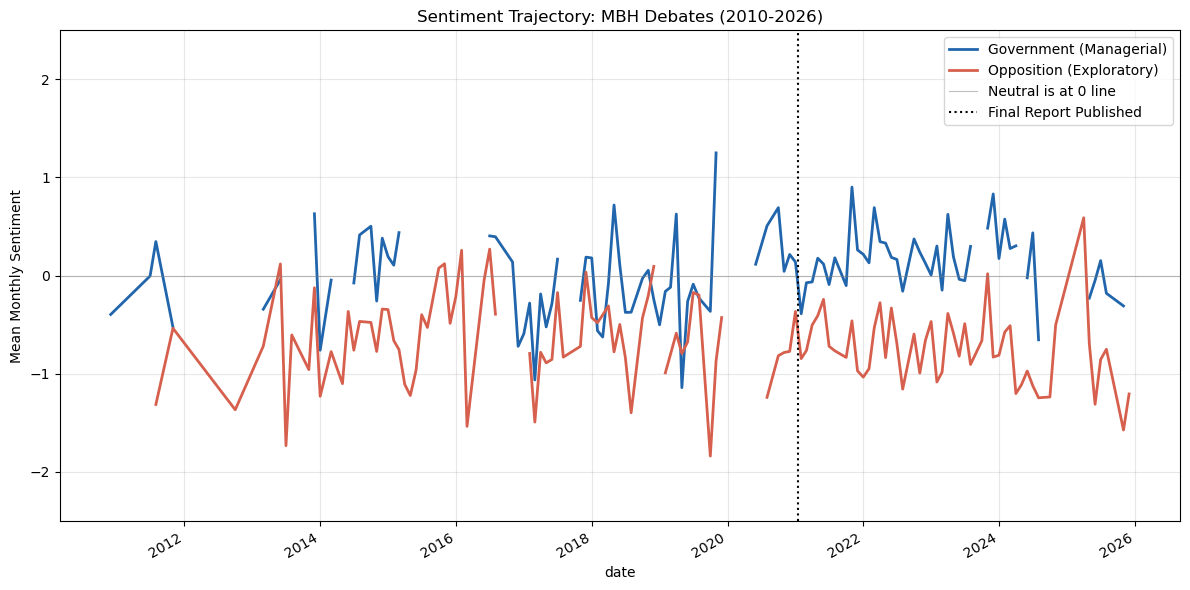

In [23]:
# Resample by Month to see trends
df_merged_clean['date'] = pd.to_datetime(df_merged_clean['date'])
ts_sentiment = (df_merged_clean.groupby([pd.Grouper(key='date', freq='M'), 'in_government'])['parlasent_sentiment_sent'].mean()- 2.5).unstack()

plt.figure(figsize=(12, 6))
ts_sentiment[1].plot(label='Government (Managerial)', color='#2166AC', linewidth=2)
ts_sentiment[0].plot(label='Opposition (Exploratory)', color='#D6604D', linewidth=2)

# Mark the Final Report Release (Jan 2021)
plt.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5, label='Neutral is at 0 line')
plt.axvline(pd.Timestamp('2021-01-12'), color='black', linestyle=':', label='Final Report Published')
plt.ylim(-2.5, 2.5)
plt.title('Sentiment Trajectory: MBH Debates (2010-2026)')
plt.ylabel('Mean Monthly Sentiment')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/sentiment_time_series.png")

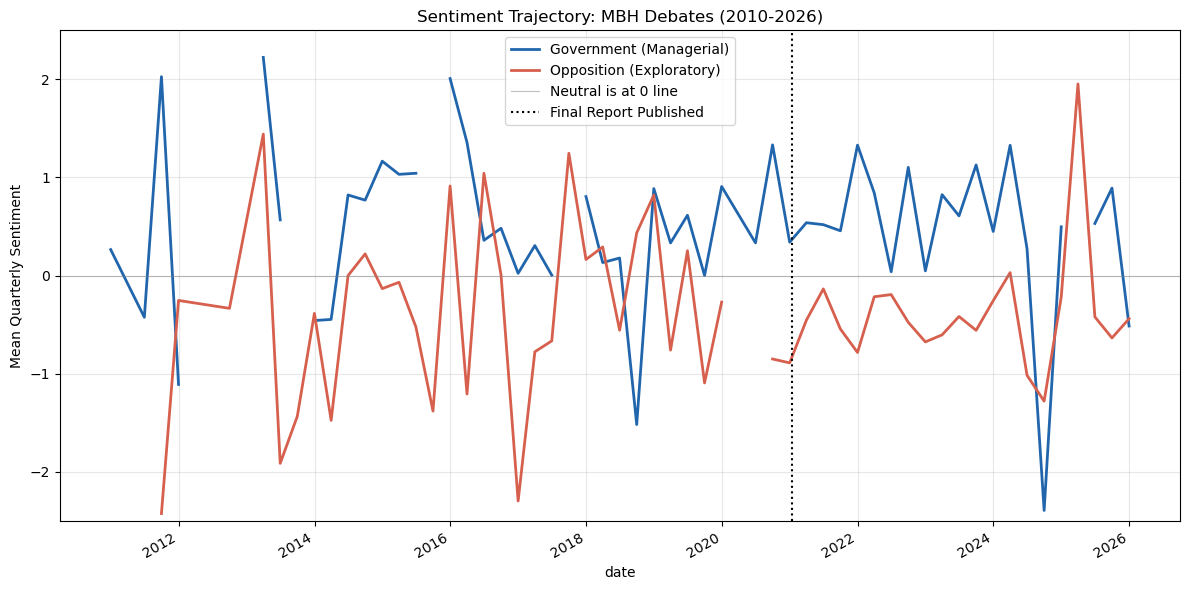

In [24]:
# Quarterly plotting to get rid of some of the jumpiness
df_merged_clean['date'] = pd.to_datetime(df_merged_clean['date'])
ts_sentiment = (df_merged_clean.groupby([pd.Grouper(key='date', freq='QE'), 'in_government'])['parlasent_sentiment'].mean() - 2.5).unstack()

plt.figure(figsize=(12, 6))
ts_sentiment[1].plot(label='Government (Managerial)', color='#2166AC', linewidth=2)
ts_sentiment[0].plot(label='Opposition (Exploratory)', color='#D6604D', linewidth=2)
plt.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5, label='Neutral is at 0 line')
plt.axvline(pd.Timestamp('2021-01-12'), color='black', linestyle=':', label='Final Report Published')
plt.ylim(-2.5, 2.5)
plt.title('Sentiment Trajectory: MBH Debates (2010-2026)')
plt.ylabel('Mean Quarterly Sentiment')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/sentiment_time_series_quarterly.png")

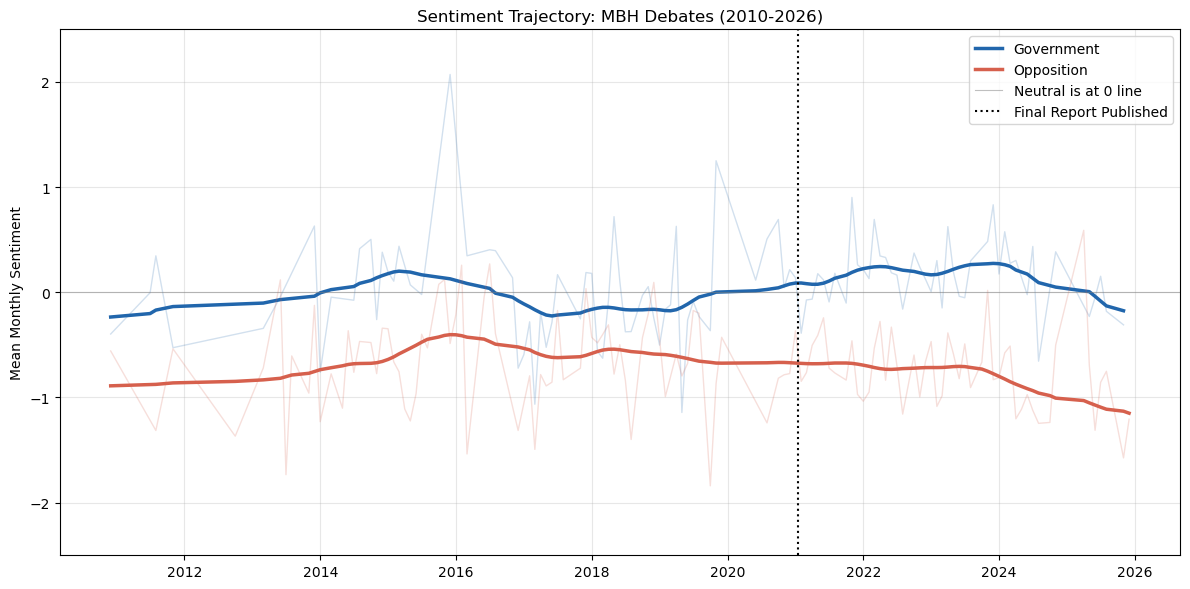

In [25]:
# Lowess smoothing monthly
df_merged_clean['date'] = pd.to_datetime(df_merged_clean['date'])
ts_sentiment = (df_merged_clean.groupby([pd.Grouper(key='date', freq='ME'), 'in_government'])['parlasent_sentiment_sent']
                .mean() - 2.5).unstack()

plt.figure(figsize=(12, 6))

for col, color, label in [
    (1, '#2166AC', 'Government'),
    (0, '#D6604D', 'Opposition')
]:
    raw = ts_sentiment[col].dropna()
    smoothed = lowess(raw.values, np.arange(len(raw)), frac=0.2) #lowess smoothing
    plt.plot(raw.index, raw.values, color=color, alpha=0.2, linewidth=1)
    plt.plot(raw.index, smoothed[:, 1], color=color, linewidth=2.5, label=label)

plt.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5, label='Neutral is at 0 line')
plt.axvline(pd.Timestamp('2021-01-12'), color='black', linestyle=':', label='Final Report Published')
plt.ylim(-2.5, 2.5)
plt.title('Sentiment Trajectory: MBH Debates (2010-2026)')
plt.ylabel('Mean Monthly Sentiment')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/sentiment_time_series_lowess.png")

In [26]:
# Find the 3 most Managerial (neutral/stable) and 3 most Exploratory (negative/intense) speeches
most_managerial = df_merged_clean[df_merged_clean['in_government']==1].nlargest(5, 'parlasent_sentiment_sent')
most_exploratory = df_merged_clean[df_merged_clean['in_government']==0].nsmallest(5, 'parlasent_sentiment_sent')

print("--- EXAMPLES OF MANAGERIAL SPEECHES (Gov) ---")
for i, row in most_managerial.iterrows():
    print(f"Date: {row['date']} | Score: {row['parlasent_sentiment_sent']:.2f}\nText: {row['clean_text'][:300]}...\n")

print("\n--- EXAMPLES OF EXPLORATORY SPEECHES (Opp) ---")
for i, row in most_exploratory.iterrows():
    print(f"Date: {row['date']} | Score: {row['parlasent_sentiment_sent']:.2f}\nText: {row['clean_text'][:300]}...\n")

--- EXAMPLES OF MANAGERIAL SPEECHES (Gov) ---
Date: 2015-11-05 00:00:00 | Score: 4.57
Text:           i welcome the final speaker mr paul redmond of the coalition of mother and baby homes survivors cmabs...

Date: 2022-05-10 00:00:00 | Score: 4.35
Text:           i thank senator boyhan for his contribution coming from where he has come and given what he said of his journey how he never imagined he would be in here when he was in one of the mother and baby homes and how he has ultimately ended up in seanad éireann speaking on legislation that affect...

Date: 2025-06-12 00:00:00 | Score: 4.27
Text:           i am pleased to be here as this is as the cathaoirleach said our first engagement i look forward to working with members of the committee the cathaoirleach and the committee staff i appreciate the manner in which many members have engaged with me on a personal basis and through the briefin...

Date: 2024-10-16 00:00:00 | Score: 4.23
Text:             i thank deputy buckley i will pu

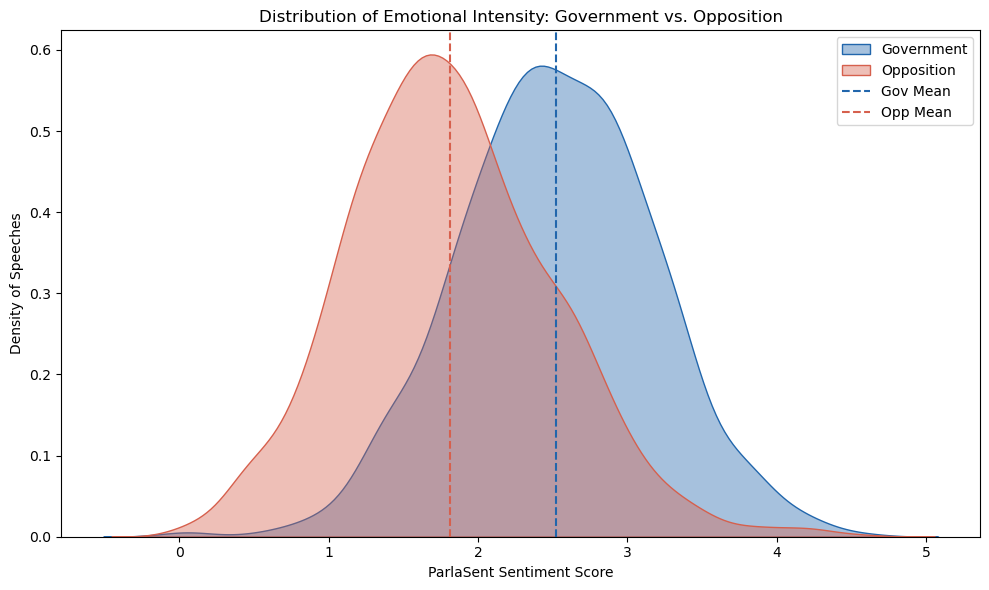

In [27]:
# Create distribution plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_merged_clean[df_merged_clean['in_government'] == 1], 
            x='parlasent_sentiment_sent', label='Government', fill=True, color='#2166AC', alpha=0.4)
sns.kdeplot(data=df_merged_clean[df_merged_clean['in_government'] == 0], 
            x='parlasent_sentiment_sent', label='Opposition', fill=True, color='#D6604D', alpha=0.4)

plt.axvline(df_merged_clean[df_merged_clean['in_government'] == 1]['parlasent_sentiment_sent'].mean(), 
            color='#2166AC', linestyle='--', label='Gov Mean')
plt.axvline(df_merged_clean[df_merged_clean['in_government'] == 0]['parlasent_sentiment_sent'].mean(), 
            color='#D6604D', linestyle='--', label='Opp Mean')

plt.title('Distribution of Emotional Intensity: Government vs. Opposition')
plt.xlabel('ParlaSent Sentiment Score')
plt.ylabel('Density of Speeches')
plt.legend()
plt.tight_layout()
plt.savefig("figures/parlasent_regime_density.png")


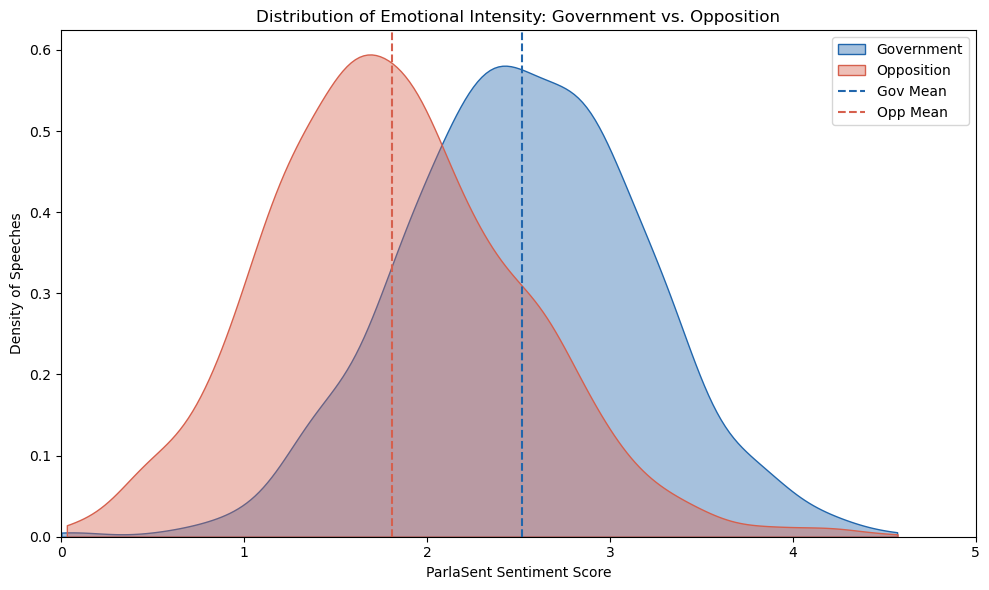

In [28]:
# Create a high-quality distribution plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_merged_clean[df_merged_clean['in_government'] == 1], 
            x='parlasent_sentiment_sent', label='Government', fill=True, color='#2166AC', alpha=0.4, cut=0)
sns.kdeplot(data=df_merged_clean[df_merged_clean['in_government'] == 0], 
            x='parlasent_sentiment_sent', label='Opposition', fill=True, color='#D6604D', alpha=0.4, cut=0)
plt.axvline(df_merged_clean[df_merged_clean['in_government'] == 1]['parlasent_sentiment_sent'].mean(), 
            color='#2166AC', linestyle='--', label='Gov Mean')
plt.axvline(df_merged_clean[df_merged_clean['in_government'] == 0]['parlasent_sentiment_sent'].mean(), 
            color='#D6604D', linestyle='--', label='Opp Mean')
plt.xlim(0, 5)
plt.title('Distribution of Emotional Intensity: Government vs. Opposition')
plt.xlabel('ParlaSent Sentiment Score')
plt.ylabel('Density of Speeches')
plt.legend()
plt.tight_layout()
plt.savefig("figures/parlasent_regime_density_0-5.png")

In [29]:
df_merged_clean.to_csv('data/df_merged_clean_sentimentscores.csv', index=False)

## Baseline/Control Group
Random sample of parliament speeches to score the sentiment analysis and things against.

In [30]:
baseline_df = pd.read_csv('data/parliamentary_baseline_cleaned.csv')


In [31]:
len(baseline_df)

2224

In [32]:
baseline_df.head()

,date,house_x,speaker,text,clean_text,text_length,speaker_norm,fullName,firstName,lastName,constituency,party,membership_start,membership_end,gender_guess,in_government
0,2010-03-23,dail,Deputy Enda Kenny,Deputy Enda Kenny\n The Minister shou...,the minister should talk about the n...,8,enda kenny,Enda Kenny,Enda,Kenny,Mayo,Fine Gael,2007-06-14,2011-02-01 00:00:00.000000,male,0
1,2012-06-12,dail,Minister for Finance (Deputy Michael Noonan),Minister for Finance (Deputy Michael Noonan)\n...,as the deputy is aware the securit...,178,michael noonan,Michael Noonan,Michael,Noonan,Limerick City,Fine Gael,2011-03-09,2016-03-09 00:00:00.000000,male,1
2,2011-10-26,dail,Deputy Richard Boyd Barrett,Deputy Richard Boyd Barrett\n I am gl...,i am glad the government finds the c...,13,richard boyd barrett,Richard Boyd Barrett,Richard,Boyd Barrett,Dún Laoghaire,People Before Profit Alliance,2011-03-09,2016-03-09 00:00:00.000000,male,0
3,2022-03-08,dail,Chairman,Chairman\n Okay.,okay,1,sean o fearghail,Seán Ó Fearghaíl,Seán,Ó Fearghaíl,Kildare South,Fianna Fáil,2020-02-08,2024-11-08 00:00:00.000000,male,1
4,2024-02-21,seanad,An Cathaoirleach,An Cathaoirleach\n Before I call on S...,before i call on senator mcgahon i w...,48,jerry buttimer,Jerry Buttimer,Jerry,Buttimer,Labour Panel,Fine Gael,2020-03-30,2024-11-29 00:00:00.000000,male,1


Same length as before so I can compare numbers

Add a binary column of "in_government" to determine which parties were part of the coalition/the government

In [33]:
print(baseline_df['in_government'].value_counts())

in_government
1    1218
0    1006
Name: count, dtype: int64


^ better distribution...

# LOG LIKELIHOOD

In [34]:
baseline_df.columns

Index(['date', 'house_x', 'speaker', 'text', 'clean_text', 'text_length',
       'speaker_norm', 'fullName', 'firstName', 'lastName', 'constituency',
       'party', 'membership_start', 'membership_end', 'gender_guess',
       'in_government'],
      dtype='object')

In [35]:
# Execute Log-Likelihood
keyness_baseline_df = get_keyness(baseline_df, 'in_government')

print("--- Statistically Significant Framing Words ---")
# LL > 3.84 is p < 0.05, LL > 10.83 is p < 0.001
display(keyness_baseline_df[keyness_baseline_df['LL'] > 10.83].head(50))

--- Statistically Significant Framing Words ---


,word,LL,typical_of,count_gov,count_opp
963,dental,86.731140,Opposition,1,53
2036,minister,81.932957,Opposition,447,543
2684,renters,65.582526,Opposition,1,41
39,2011,57.915315,Government,84,5
38,2010,55.134587,Government,72,3
934,defence,54.222847,Government,99,10
2308,people,46.800595,Opposition,537,555
506,britain,43.124974,Opposition,4,36
1052,does,42.135957,Opposition,133,188
3150,taoiseach,41.916147,Opposition,34,81


In [36]:
# Top 50 for Government
gov_top_50_baseline = keyness_baseline_df[
    (keyness_baseline_df['typical_of'] == 'Government') & (keyness_baseline_df['LL'] > 10.83)
].head(50)

# Top 50 for Opposition
gov_top_50_baseline = keyness_baseline_df[
    (keyness_baseline_df['typical_of'] == 'Opposition') & (keyness_baseline_df['LL'] > 10.83)
].head(50)

print("--- TOP 50 GOVERNMENT KEY WORDS ---")
display(gov_top_50_baseline[['word', 'LL', 'count_gov', 'count_opp']])

print("\n--- TOP 50 OPPOSITION KEY WORDS ---")
display(gov_top_50_baseline[['word', 'LL', 'count_gov', 'count_opp']])

--- TOP 50 GOVERNMENT KEY WORDS ---


,word,LL,count_gov,count_opp
963,dental,86.731140,1,53
2036,minister,81.932957,447,543
2684,renters,65.582526,1,41
2308,people,46.800595,537,555
506,britain,43.124974,4,36
1052,does,42.135957,133,188
3150,taoiseach,41.916147,34,81
2591,records,36.671275,10,43
1477,government,35.742350,336,361
1584,housing,35.548235,76,122



--- TOP 50 OPPOSITION KEY WORDS ---


,word,LL,count_gov,count_opp
963,dental,86.731140,1,53
2036,minister,81.932957,447,543
2684,renters,65.582526,1,41
2308,people,46.800595,537,555
506,britain,43.124974,4,36
1052,does,42.135957,133,188
3150,taoiseach,41.916147,34,81
2591,records,36.671275,10,43
1477,government,35.742350,336,361
1584,housing,35.548235,76,122


In [37]:
# Frequency Filter (e.g. Min 5 occurrences across the whole corpus)
min_frequency = 0
keyness_baseline_df['total_count'] = keyness_baseline_df['count_gov'] + keyness_baseline_df['count_opp']
keyness_baseline_df = keyness_baseline_df[keyness_baseline_df['total_count'] >= min_frequency].copy()

# Calculate Log-Ratio to determine effect size (how much more likely a group uses a word)
# Add small constant to avoid division by zeros
keyness_baseline_df['rel_gov'] = (keyness_baseline_df['count_gov'] + 0.1) / keyness_baseline_df['count_gov'].sum() #+ 0.1 is a "smoothing" technique- if a word appears 0 times in the Opposition text, you can't divide by zero, so adding 0.1 allows
keyness_baseline_df['rel_opp'] = (keyness_baseline_df['count_opp'] + 0.1) / keyness_baseline_df['count_opp'].sum()
keyness_baseline_df['log_ratio'] = np.log2(keyness_baseline_df['rel_gov'] / keyness_baseline_df['rel_opp'])

# Identify Managerial vs. Exploratory Framing
managerial_words = keyness_baseline_df[keyness_baseline_df['log_ratio'] > 1].sort_values('log_ratio', ascending=False).head(20)
exploratory_words = keyness_baseline_df[keyness_baseline_df['log_ratio'] < -1].sort_values('log_ratio', ascending=True).head(20)

print("--- TOP MANAGERIAL FRAMES (Gov more likely) ---")
print(managerial_words[['word', 'log_ratio']])

print("\n--- TOP EXPLORATORY FRAMES (Opp more likely) ---")
print(exploratory_words[['word', 'log_ratio']])

--- TOP MANAGERIAL FRAMES (Gov more likely) ---
                 word  log_ratio
569              cash   7.819381
1596              ida   7.530843
227              agam   7.169793
1876          library   7.026123
680          combined   7.026123
1428              fás   7.026123
2603       reductions   7.026123
2172             oecd   6.866547
3356         vehicles   6.779611
1038         disposal   6.588245
1767            items   6.588245
2855      secretaries   6.482117
266        allowances   6.482117
2752           retail   6.482117
2590         recorded   6.482117
415          aviation   6.482117
2765         reviewed   6.367557
2701  representations   6.367557
634          civilian   6.243110
663             coast   6.243110

--- TOP EXPLORATORY FRAMES (Opp more likely) ---
             word  log_ratio
1211   eventually  -7.470169
975   dereliction  -7.470169
587       century  -6.891156
2214          opt  -6.891156
404     austerity  -6.701053
338        argued  -6.701053
306   

In [38]:
pd.set_option('display.max_rows', None)

# Words appearing only in Government
gov_only_baseline = keyness_baseline_df[(keyness_baseline_df['count_gov'] > 0) & (keyness_baseline_df['count_opp'] == 0)]
print("--- Words ONLY in Government Baseline ---")
print(gov_only_baseline[['word', 'count_gov', 'count_opp']])

# Words appearing only in Opposition
opp_only_baseline = keyness_baseline_df[(keyness_baseline_df['count_opp'] > 0) & (keyness_baseline_df['count_gov'] == 0)]
print("\n--- Words ONLY in Opposition Baseline ---")
print(opp_only_baseline[['word', 'count_gov', 'count_opp']])

# # Words appearing in BOTH
# both = keyness_baseline_df[(keyness_baseline_df['count_gov'] > 0) & (keyness_baseline_df['count_opp'] > 0)]
# print("\n--- Words in BOTH Government and Opposition ---")
# print(both[['word', 'count_gov', 'count_opp']])


--- Words ONLY in Government Baseline ---
                 word  count_gov  count_opp
569              cash         33          0
1596              ida         27          0
227              agam         21          0
1876          library         19          0
680          combined         19          0
1428              fás         19          0
2603       reductions         19          0
2172             oecd         17          0
3356         vehicles         16          0
1038         disposal         14          0
1767            items         14          0
2752           retail         13          0
266        allowances         13          0
2855      secretaries         13          0
415          aviation         13          0
2590         recorded         13          0
2701  representations         12          0
2765         reviewed         12          0
634          civilian         11          0
663             coast         11          0
2119             ngos         11  

# PARLASENT

In [39]:
baseline_df['clean_text'].isna().sum()

np.int64(0)

In [40]:
print(baseline_df.columns.tolist())

['date', 'house_x', 'speaker', 'text', 'clean_text', 'text_length', 'speaker_norm', 'fullName', 'firstName', 'lastName', 'constituency', 'party', 'membership_start', 'membership_end', 'gender_guess', 'in_government']


In [41]:
# set to true if parlasent should be rerun
RERUN_BASELINE_PARLASENT = False

if RERUN_BASELINE_PARLASENT:
    # Strip speaker name but keep punctuation for sentence tokenization
    baseline_df['text_for_sent'] = baseline_df['text'].apply(
        remove_speaker_name_only)
    baseline_df['sentences'] = baseline_df['text_for_sent'].fillna(
        "").apply(sent_tokenize)

    records_baseline = []
    for idx, row in baseline_df.iterrows():
        for sent in row['sentences']:
            if len(sent.strip()) > 10:
                records_baseline.append({'speech_idx': idx, 'sentence': sent})

    sentences_baseline_df = pd.DataFrame(records_baseline)
    print(f"Total baseline sentences: {len(sentences_baseline_df)}")

    # Run ParlaSent (~18 minutes on CPU)
    print("Running ParlaSent on baseline sentences...")
    predictions_b, raw_outputs_b = parlasent_model.predict(
        sentences_baseline_df['sentence'].tolist()
    )
    sentences_baseline_df['sent_score'] = [float(logits[0]) 
                                            for logits in raw_outputs_b]
    sentences_baseline_df['sent_score'] = sentences_baseline_df[
        'sent_score'].clip(0, 5)

    baseline_sentiment = sentences_baseline_df.groupby(
        'speech_idx')['sent_score'].mean()
    baseline_df['parlasent_sentiment_sent'] = baseline_df.index.map(
        baseline_sentiment)

    # Save to disk
    baseline_df.to_csv('data/df_baseline_cleaned_sentimentscores.csv', 
                       index=False)
    print("Saved to data/df_baseline_cleaned_sentimentscores.csv")

else:
    print("Loading precomputed baseline scores from disk...")
    baseline_df = pd.read_csv('data/df_baseline_cleaned_sentimentscores.csv')
    baseline_df['date'] = pd.to_datetime(baseline_df['date'])
    print("Loaded.")

# Calculate baseline Cohen's d
gov_b = baseline_df[baseline_df['in_government'] == 1]['parlasent_sentiment_sent']
opp_b = baseline_df[baseline_df['in_government'] == 0]['parlasent_sentiment_sent']

d_baseline = (gov_b.mean() - opp_b.mean()) / np.sqrt(
    (gov_b.std()**2 + opp_b.std()**2) / 2)

print(f"Baseline Cohen's d: {d_baseline:.3f}")
print(f"MBH Cohen's d: 1.057")
print(f"Amplification factor: {1.057 / d_baseline:.2f}x")

Loading precomputed baseline scores from disk...
Loaded.
Baseline Cohen's d: 0.314
MBH Cohen's d: 1.057
Amplification factor: 3.36x


In [42]:
# Calculate Variance and Mean
regime_stats_baseline = baseline_df.groupby('in_government')['parlasent_sentiment_sent'].agg(['mean', 'std', 'var', 'count']).reset_index()
regime_stats_baseline['Regime'] = regime_stats_baseline['in_government'].map({1: 'Managerial (Gov)', 0: 'Exploratory (Opp)'})
print(regime_stats_baseline[['Regime', 'mean', 'std', 'count']])

# Statistical Significance (Mann-Whitney U Test)
u_stat, p_val = mannwhitneyu(baseline_df[baseline_df['in_government']==1]['parlasent_sentiment_sent'],
                              baseline_df[baseline_df['in_government']==0]['parlasent_sentiment_sent'])
print(f"\nSignificance of the Sentiment Gap (p-value): {p_val:.5f}")

              Regime      mean       std  count
0  Exploratory (Opp)  2.238863  1.160877    975
1   Managerial (Gov)  2.587667  1.055634   1175

Significance of the Sentiment Gap (p-value): nan


In [43]:
gov = baseline_df[baseline_df['in_government']==1]['parlasent_sentiment_sent'].dropna()
opp = baseline_df[baseline_df['in_government']==0]['parlasent_sentiment_sent'].dropna()

print(f"Gov n: {len(gov)}, Opp n: {len(opp)}")

u_stat, p_val = mannwhitneyu(gov, opp)
print(f"U: {u_stat}, p: {p_val:}")

Gov n: 1175, Opp n: 975
U: 685455.5, p: 3.825166960471357e-15


/var/folders/__/k0nszvtx03q_x5mm5gp8l0v40000gn/T/ipykernel_5766/356060779.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_sentiment = (baseline_df.groupby([pd.Grouper(key='date', freq='M'), 'in_government'])['parlasent_sentiment_sent'].mean()-2.5).unstack()


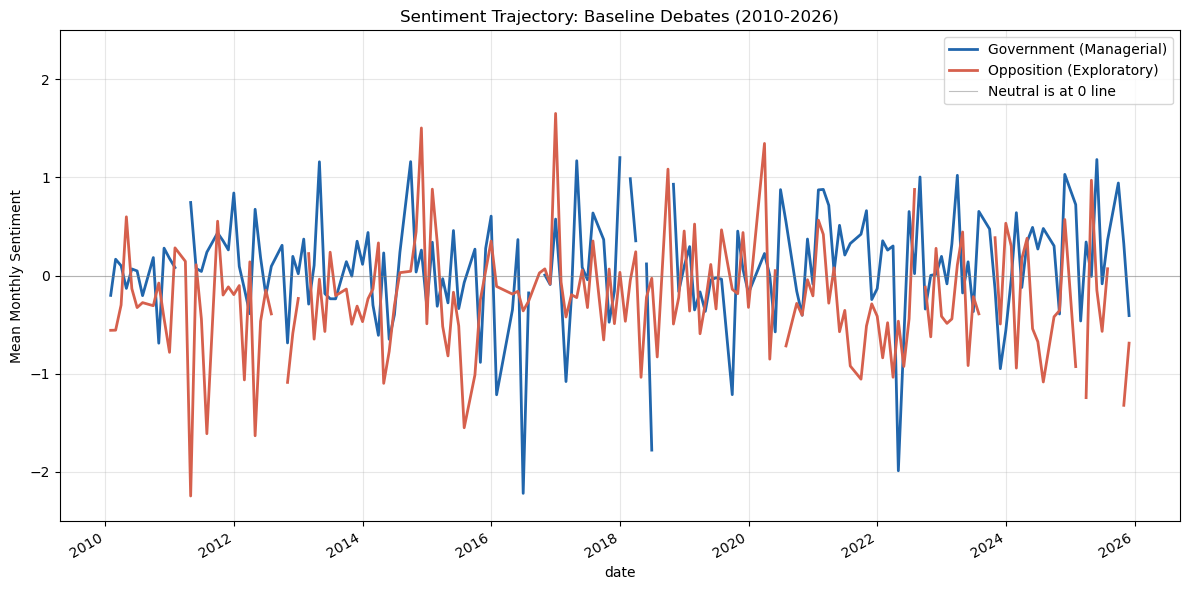

In [44]:
# Resample by Month to see trends
baseline_df['date'] = pd.to_datetime(baseline_df['date'])
ts_sentiment = (baseline_df.groupby([pd.Grouper(key='date', freq='M'), 'in_government'])['parlasent_sentiment_sent'].mean()-2.5).unstack()

plt.figure(figsize=(12, 6))
ts_sentiment[1].plot(label='Government (Managerial)', color='#2166AC', linewidth=2)
ts_sentiment[0].plot(label='Opposition (Exploratory)', color='#D6604D', linewidth=2)

plt.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5, label='Neutral is at 0 line')
plt.ylim(-2.5, 2.5)

plt.title('Sentiment Trajectory: Baseline Debates (2010-2026)')
plt.ylabel('Mean Monthly Sentiment')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/baseline_sentiment_time_series.png")

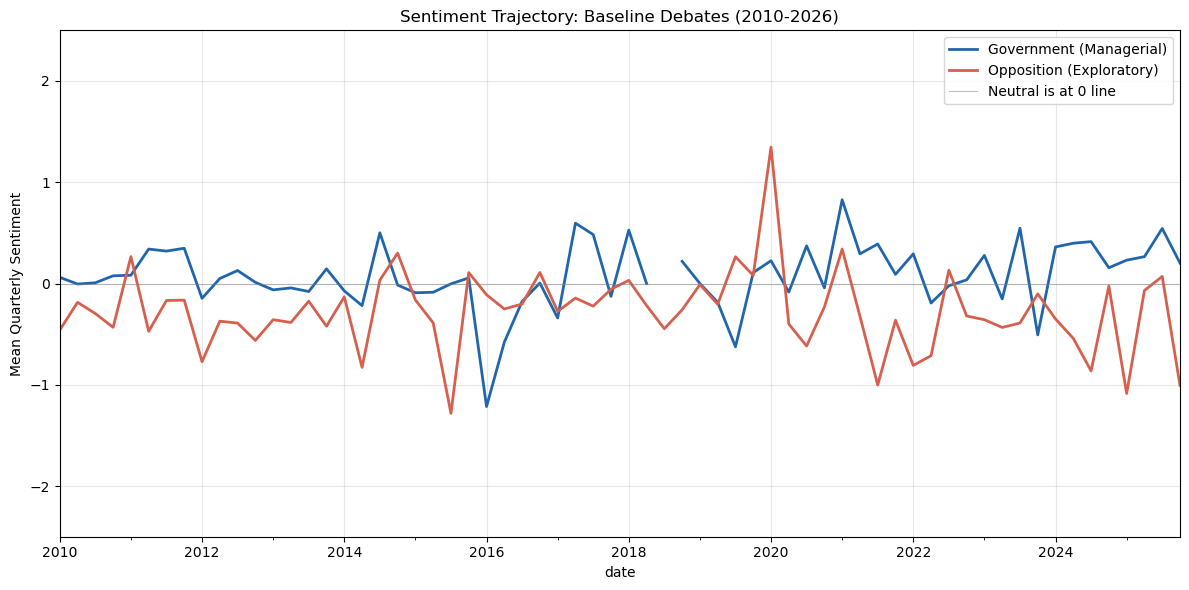

In [45]:
# Quarterly plotting to get rid of some of the jumpiness
baseline_df['date'] = pd.to_datetime(baseline_df['date'])
ts_sentiment = (baseline_df.groupby([pd.Grouper(key='date', freq='QE'), 'in_government'])['parlasent_sentiment_sent'].mean()-2.5).unstack()

plt.figure(figsize=(12, 6))
ts_sentiment[1].plot(label='Government (Managerial)', color='#2166AC', linewidth=2)
ts_sentiment[0].plot(label='Opposition (Exploratory)', color='#D6604D', linewidth=2)

plt.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5, label='Neutral is at 0 line')
plt.ylim(-2.5, 2.5)

plt.title('Sentiment Trajectory: Baseline Debates (2010-2026)')
plt.ylabel('Mean Quarterly Sentiment')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/baseline_sentiment_time_series_quarterly.png")

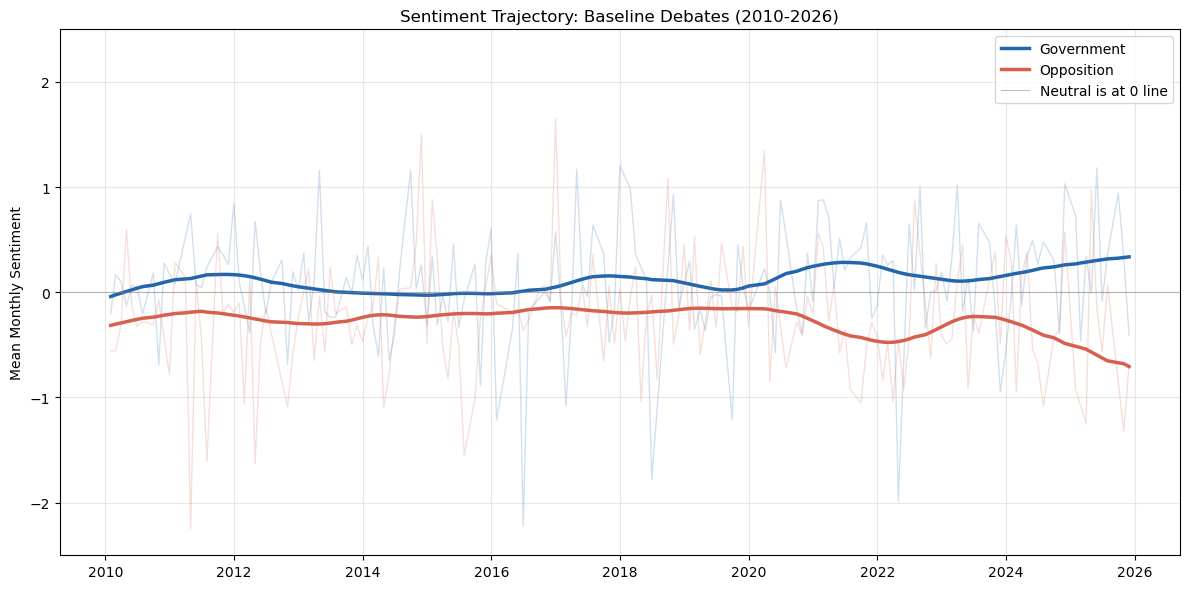

In [46]:
# Lowess smoothing monthly
baseline_df['date'] = pd.to_datetime(baseline_df['date'])
ts_sentiment = (baseline_df.groupby([pd.Grouper(key='date', freq='ME'), 'in_government'])['parlasent_sentiment_sent'].mean()-2.5).unstack()

plt.figure(figsize=(12, 6))

for col, color, label in [
    (1, '#2166AC', 'Government'),
    (0, '#D6604D', 'Opposition')
]:
    raw = ts_sentiment[col].dropna()
    smoothed = lowess(raw.values, np.arange(len(raw)), frac=0.2) #lowess smoothing
    plt.plot(raw.index, raw.values, color=color, alpha=0.2, linewidth=1)
    plt.plot(raw.index, smoothed[:, 1], color=color, linewidth=2.5, label=label)


plt.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5, label='Neutral is at 0 line')
plt.ylim(-2.5, 2.5)

plt.title('Sentiment Trajectory: Baseline Debates (2010-2026)')
plt.ylabel('Mean Monthly Sentiment')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/baseline_sentiment_time_series_lowess.png")

In [47]:
# Find the 3 most Managerial (neutral/stable) and 3 most Exploratory (negative/intense) speeches
most_managerial = baseline_df[baseline_df['in_government']==1].nlargest(5, 'parlasent_sentiment_sent')
most_exploratory = baseline_df[baseline_df['in_government']==0].nsmallest(5, 'parlasent_sentiment_sent')

print("--- EXAMPLES OF Baseline MANAGERIAL SPEECHES (Gov) ---")
for i, row in most_managerial.iterrows():
    print(f"Date: {row['date']} | Score: {row['parlasent_sentiment_sent']:.2f}\nText: {row['clean_text'][:300]}...\n")

print("\n--- EXAMPLES OF Baseline EXPLORATORY SPEECHES (Opp) ---")
for i, row in most_exploratory.iterrows():
    print(f"Date: {row['date']} | Score: {row['parlasent_sentiment_sent']:.2f}\nText: {row['clean_text'][:300]}...\n")

--- EXAMPLES OF Baseline MANAGERIAL SPEECHES (Gov) ---
Date: 2014-04-09 00:00:00 | Score: 5.00
Text:           i am happy with dr finnegans first response...

Date: 2013-12-04 00:00:00 | Score: 5.00
Text:           that is a good answer...

Date: 2017-05-09 00:00:00 | Score: 5.00
Text:           i am doing my best to get there...

Date: 2024-11-05 00:00:00 | Score: 5.00
Text:           i congratulate the minister on having achieved such unanimity...

Date: 2024-04-30 00:00:00 | Score: 5.00
Text:           i appreciate that...


--- EXAMPLES OF Baseline EXPLORATORY SPEECHES (Opp) ---
Date: 2022-02-09 00:00:00 | Score: 0.00
Text:           people are surviving with sickness...

Date: 2022-12-08 00:00:00 | Score: 0.00
Text:           pli wanted to prevent the public from knowing about one of the key issues that has been of public concern and concern to this committee...

Date: 2012-11-22 00:00:00 | Score: 0.00
Text:           the government is in office two years and the problem has conti

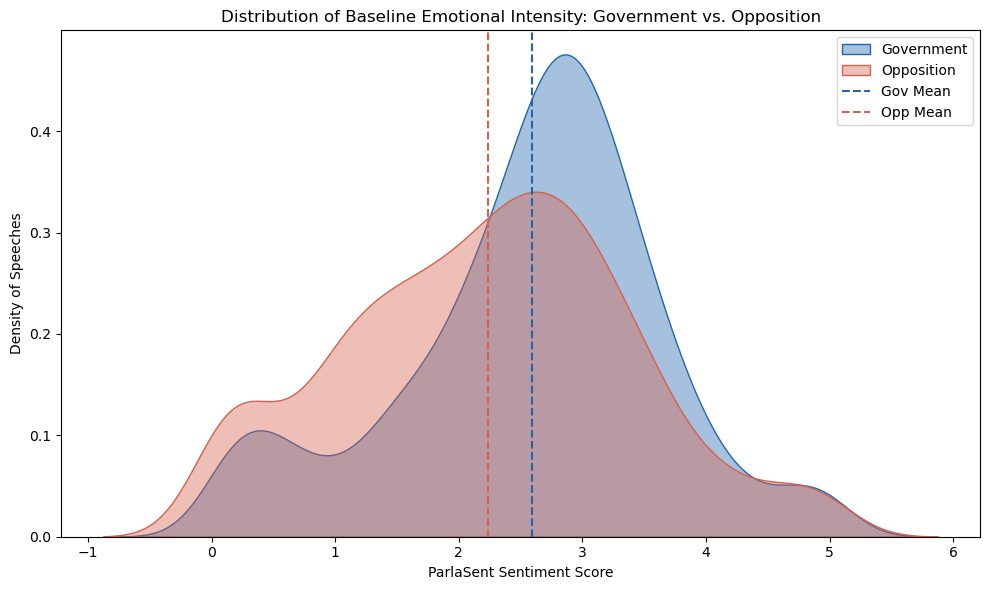

In [48]:
# Create distribution plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=baseline_df[baseline_df['in_government'] == 1], 
            x='parlasent_sentiment_sent', label='Government', fill=True, color='#2166AC', alpha=0.4)
sns.kdeplot(data=baseline_df[baseline_df['in_government'] == 0], 
            x='parlasent_sentiment_sent', label='Opposition', fill=True, color='#D6604D', alpha=0.4)

plt.axvline(baseline_df[baseline_df['in_government'] == 1]['parlasent_sentiment_sent'].mean(), 
            color='#2166AC', linestyle='--', label='Gov Mean')
plt.axvline(baseline_df[baseline_df['in_government'] == 0]['parlasent_sentiment_sent'].mean(), 
            color='#D6604D', linestyle='--', label='Opp Mean')

plt.title('Distribution of Baseline Emotional Intensity: Government vs. Opposition')
plt.xlabel('ParlaSent Sentiment Score')
plt.ylabel('Density of Speeches')
plt.legend()
plt.tight_layout()
plt.savefig("figures/baseline_parlasent_regime_density.png")


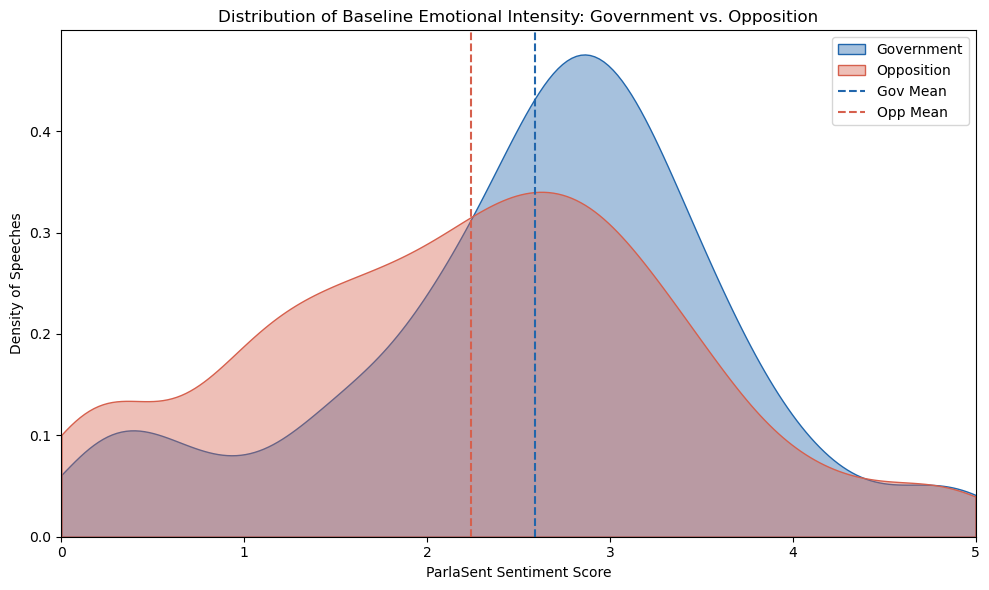

In [49]:
# Create a distribution plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=baseline_df[baseline_df['in_government'] == 1], 
            x='parlasent_sentiment_sent', label='Government', fill=True, color='#2166AC', alpha=0.4, cut=0)
sns.kdeplot(data=baseline_df[baseline_df['in_government'] == 0], 
            x='parlasent_sentiment_sent', label='Opposition', fill=True, color='#D6604D', alpha=0.4, cut=0)
plt.axvline(baseline_df[baseline_df['in_government'] == 1]['parlasent_sentiment_sent'].mean(), 
            color='#2166AC', linestyle='--', label='Gov Mean')
plt.axvline(baseline_df[baseline_df['in_government'] == 0]['parlasent_sentiment_sent'].mean(), 
            color='#D6604D', linestyle='--', label='Opp Mean')
plt.xlim(0, 5)
plt.title('Distribution of Baseline Emotional Intensity: Government vs. Opposition')
plt.xlabel('ParlaSent Sentiment Score')
plt.ylabel('Density of Speeches')
plt.legend()
plt.tight_layout()
plt.savefig("figures/baseline_parlasent_regime_density_0-5.png")



In [50]:
baseline_df.to_csv('data/df_baseline_cleaned_sentimentscores.csv', index=False)

In [51]:
baseline_df['parlasent_sentiment_sent'].describe()

count    2150.000000
mean        2.429488
std         1.117917
min         0.000000
25%         1.700046
50%         2.573277
75%         3.163702
max         5.000000
Name: parlasent_sentiment_sent, dtype: float64

In [52]:
df_merged_clean['parlasent_sentiment_sent'].describe()

count    2224.000000
mean        2.077768
std         0.758922
min         0.000000
25%         1.543151
50%         2.039834
75%         2.605771
max         4.573372
Name: parlasent_sentiment_sent, dtype: float64

In [53]:
# Summary Statistics
# Data
gov_mbh = df_merged_clean[df_merged_clean['in_government']==1]['parlasent_sentiment_sent']
opp_mbh = df_merged_clean[df_merged_clean['in_government']==0]['parlasent_sentiment_sent']

gov_base = baseline_df[baseline_df['in_government']==1]['parlasent_sentiment_sent']
opp_base = baseline_df[baseline_df['in_government']==0]['parlasent_sentiment_sent']

# Cohen's d function
def cohens_d(group1, group2):
    diff = group1.mean() - group2.mean()
    pooled_std = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
    return diff / pooled_std

# Effect Sizes
d_mbh  = cohens_d(gov_mbh, opp_mbh)
d_base = cohens_d(gov_base, opp_base)

# Raw gaps
gap_mbh  = abs(gov_mbh.mean()  - opp_mbh.mean())
gap_base = abs(gov_base.mean() - opp_base.mean())

# Significance
_, p_mbh  = mannwhitneyu(gov_mbh, opp_mbh)
_, p_base = mannwhitneyu(gov_base, opp_base)

# Summary
print("=" * 55)
print(f"{'':20} {'Baseline':>15} {'MBH':>15}")
print("=" * 55)
print(f"{'Gov Mean':20} {gov_base.mean():>15.3f} {gov_mbh.mean():>15.3f}")
print(f"{'Opp Mean':20} {opp_base.mean():>15.3f} {opp_mbh.mean():>15.3f}")
print(f"{'Raw Gap':20} {gap_base:>15.3f} {gap_mbh:>15.3f}")
cohens_label = "Cohen's d"
print(f"{cohens_label:20} {d_base:>15.3f} {d_mbh:>15.3f}")
print("=" * 55)
print(f"\nEffect size amplification: {abs(d_mbh)/abs(d_base):.2f}x larger in MBH")

                            Baseline             MBH
Gov Mean                       2.588           2.520
Opp Mean                       2.239           1.809
Raw Gap                        0.349           0.710
Cohen's d                      0.314           1.057

Effect size amplification: 3.36x larger in MBH


# Go to R for STM Topic Modelling